# Loss visualization of GAN training

In [1]:
import os
import torch
import torch.nn as nn
import numpy as np
import pyvista as pv
import pandas as pd
import matplotlib.pyplot as plt
from functools import partial
from voxgan.networks import resnet

c:\Users\mathi\miniconda3\envs\fluvgan\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
c:\Users\mathi\miniconda3\envs\fluvgan\Lib\site-packages\voxgan\models\base.py:46: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import ZeroRedundancyOptimizer


In [30]:
file = "fluvgan_1_training_1_architecture_4_dcgan_one_hot_1_history.csv"
loss = pd.read_csv(file)

#loss_max_iter = loss[loss["iteration"]%224==0] 

In [31]:
loss

,epoch,batch,iteration,update,loss_discriminator,D(x),loss_generator,D(G(z)),D_up(G(z)),checkpoint,MS-SWD,LoS,sampling
0,1,1,1,1,1.444889,-2.783203,1.542242,-3.042969,-3.037109,True,0.448820,0.494882,True
1,1,2,2,1,1.377802,-2.636719,1.534559,-3.027344,-3.021484,False,0.374067,NaN,False
2,1,3,3,1,1.445144,-2.750000,1.363191,-2.652344,-2.650391,False,0.458052,NaN,False
3,1,4,4,1,1.495795,-2.861328,1.373160,-2.675781,-2.671875,False,NaN,NaN,False
4,1,5,5,1,1.498694,-2.833984,1.155842,-2.207031,-2.207031,False,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
22445,50,445,22446,1,0.499219,1.283203,0.639511,0.115845,-0.952637,False,NaN,NaN,False
22446,50,446,22447,1,0.619347,-0.321045,0.584850,-0.798828,-0.797852,False,NaN,NaN,False
22447,50,447,22448,1,0.619996,-0.276855,0.253822,-0.768066,0.414551,False,NaN,NaN,False
22448,50,448,22449,1,0.595369,1.462891,0.235628,0.511230,0.509766,False,NaN,NaN,False


In [32]:
loss_max_iter=loss[loss["MS-SWD"].isna()==False]
loss_max_iter

,epoch,batch,iteration,update,loss_discriminator,D(x),loss_generator,D(G(z)),D_up(G(z)),checkpoint,MS-SWD,LoS,sampling
0,1,1,1,1,1.444889,-2.783203,1.542242,-3.042969,-3.037109,True,0.448820,0.494882,True
1,1,2,2,1,1.377802,-2.636719,1.534559,-3.027344,-3.021484,False,0.374067,NaN,False
2,1,3,3,1,1.445144,-2.750000,1.363191,-2.652344,-2.650391,False,0.458052,NaN,False
300,1,301,301,1,0.698405,0.745117,0.226809,0.554688,0.555176,False,0.155020,0.492578,True
301,1,302,302,1,0.696105,0.750000,0.539632,0.549805,-0.664062,False,0.208610,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21901,49,350,21902,1,0.616040,-0.306396,0.355014,-0.791992,-0.033356,False,0.046037,NaN,False
21902,49,351,21903,1,0.513210,1.035156,0.332814,0.055939,0.056396,False,0.018242,NaN,False
22200,50,200,22201,1,0.531103,1.067383,0.312621,0.141235,0.141357,False,0.013925,0.566913,True
22201,50,201,22202,1,0.540340,1.009766,0.540175,0.145386,-0.665039,False,0.020336,NaN,False


Text(0.5, 0, 'Epoch')

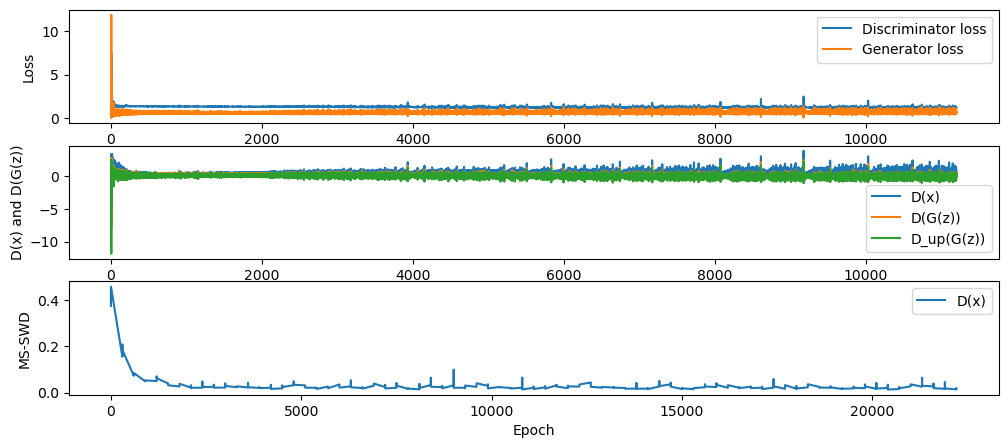

In [ ]:
x = loss["iteration"]

plt.figure(figsize=(12, 5))

plt.subplot(3,1,1)
plt.plot(x, loss["loss_discriminator"], label="Discriminator loss")
plt.plot(x, loss["loss_generator"], label="Generator loss")
plt.legend()
plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.subplot(3,1,2)
plt.plot(x, loss["D(x)"], label="D(x)")
plt.plot(x, loss["D(G(z))"], label="D(G(z))")
plt.plot(x, loss["D_up(G(z))"], label="D_up(G(z))")
plt.legend()
plt.ylabel("D(x) and D(G(z))")
plt.xlabel("Epoch")

x = loss_max_iter["iteration"]

plt.subplot(3,1,3)
plt.plot(x, loss_max_iter["MS-SWD"], label="D(x)")
plt.legend()
plt.ylabel("MS-SWD")
plt.xlabel("Epoch")

## Continuous values

Text(0.5, 0, 'Epoch')

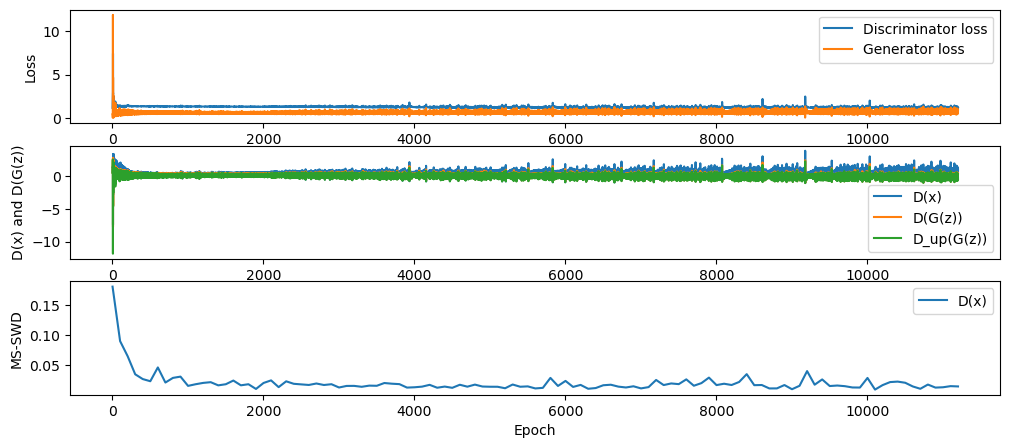

In [38]:
data = pd.read_csv("fluvgan_1_training_1_architecture_dcgan_4_1_history.csv")

loss = data

x = loss["iteration"]

plt.figure(figsize=(12, 5))

plt.subplot(3,1,1)
plt.plot(x, loss["loss_discriminator"], label="Discriminator loss")
plt.plot(x, loss["loss_generator"], label="Generator loss")
plt.legend()
plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.subplot(3,1,2)
plt.plot(x, loss["D(x)"], label="D(x)")
plt.plot(x, loss["D(G(z))"], label="D(G(z))")
plt.plot(x, loss["D_up(G(z))"], label="D_up(G(z))")
plt.legend()
plt.ylabel("D(x) and D(G(z))")
plt.xlabel("Epoch")

loss_max_iter=loss[loss["MS-SWD"].isna()==False]
loss_max_iter
x = loss_max_iter["iteration"]

plt.subplot(3,1,3)
plt.plot(x, loss_max_iter["MS-SWD"], label="D(x)")
plt.legend()
plt.ylabel("MS-SWD")
plt.xlabel("Epoch")

In [17]:
# --- 1. The True Architecture ---
nz = 100
nc = 1               
ngf = 64             
max_factor = 16      
nl = (4, 6, 6)       # THE FIX: This perfectly aligns with the (3, 3, 3) kernels in the checkpoint
checkpoint_path = "fluvgan_1_training_1_architecture_dcgan_4_1_training_checkpoint_iteration_11200.pt"

print("Building Generator...")
gen_layer = resnet.DeepGenerator3d(
    nz=nz,
    ngf=ngf,
    nc=nc,
    nl=nl,
    max_factor=max_factor,
    residual_weight=1.,
    mode='nearest',
    kernel_size=3,
    layer_normalization=nn.BatchNorm3d,
    last_layer_normalization=nn.BatchNorm3d,
    weight_normalization=nn.utils.parametrizations.spectral_norm,
    activation=partial(nn.LeakyReLU, negative_slope=0.2, inplace=True),
    last_activation=nn.Tanh,
    use_double_conv=False,
    use_double_resblocks=False,
    use_attention=False,
    skip_z=False,
    split_z=False
)

# --- 2. The DataParallel Loading Trick ---
print("Loading Checkpoint...")
checkpoint = torch.load(checkpoint_path, map_location='cpu')

gen_state = checkpoint['generator']
if 'state_dict' in gen_state:
    gen_state = gen_state['state_dict']

# Wrap local model to accept 'module.' keys from the multi-GPU training
gen_layer = nn.DataParallel(gen_layer)
gen_layer.load_state_dict(gen_state, strict=False)

# Unwrap
gen_layer = gen_layer.module
gen_layer.eval()
print("Success! Weights are perfectly aligned.")

# --- 3. Generate the 3D Sample ---
print("Generating 3D River Block...")

# Detect if your computer has a GPU, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move the model to the correct device
gen_layer = gen_layer.to(device)

Building Generator...
Loading Checkpoint...
Success! Weights are perfectly aligned.
Generating 3D River Block...


In [18]:
with torch.no_grad():
    # 5D input required by this architecture, moved to the exact same device!
    z = torch.randn(1, nz).to(device)
    z_input = z.view(z.shape + (1, 1, 1)) 
    
    output = gen_layer(z_input)
    sample = output['data'].cpu().numpy() if isinstance(output, dict) else output.cpu().numpy()

# Extract: (Batch, Channel, D, H, W) -> (D, H, W)
volume = sample[0, 0, :, :, :]

Generated volume shape: (64, 256, 256)


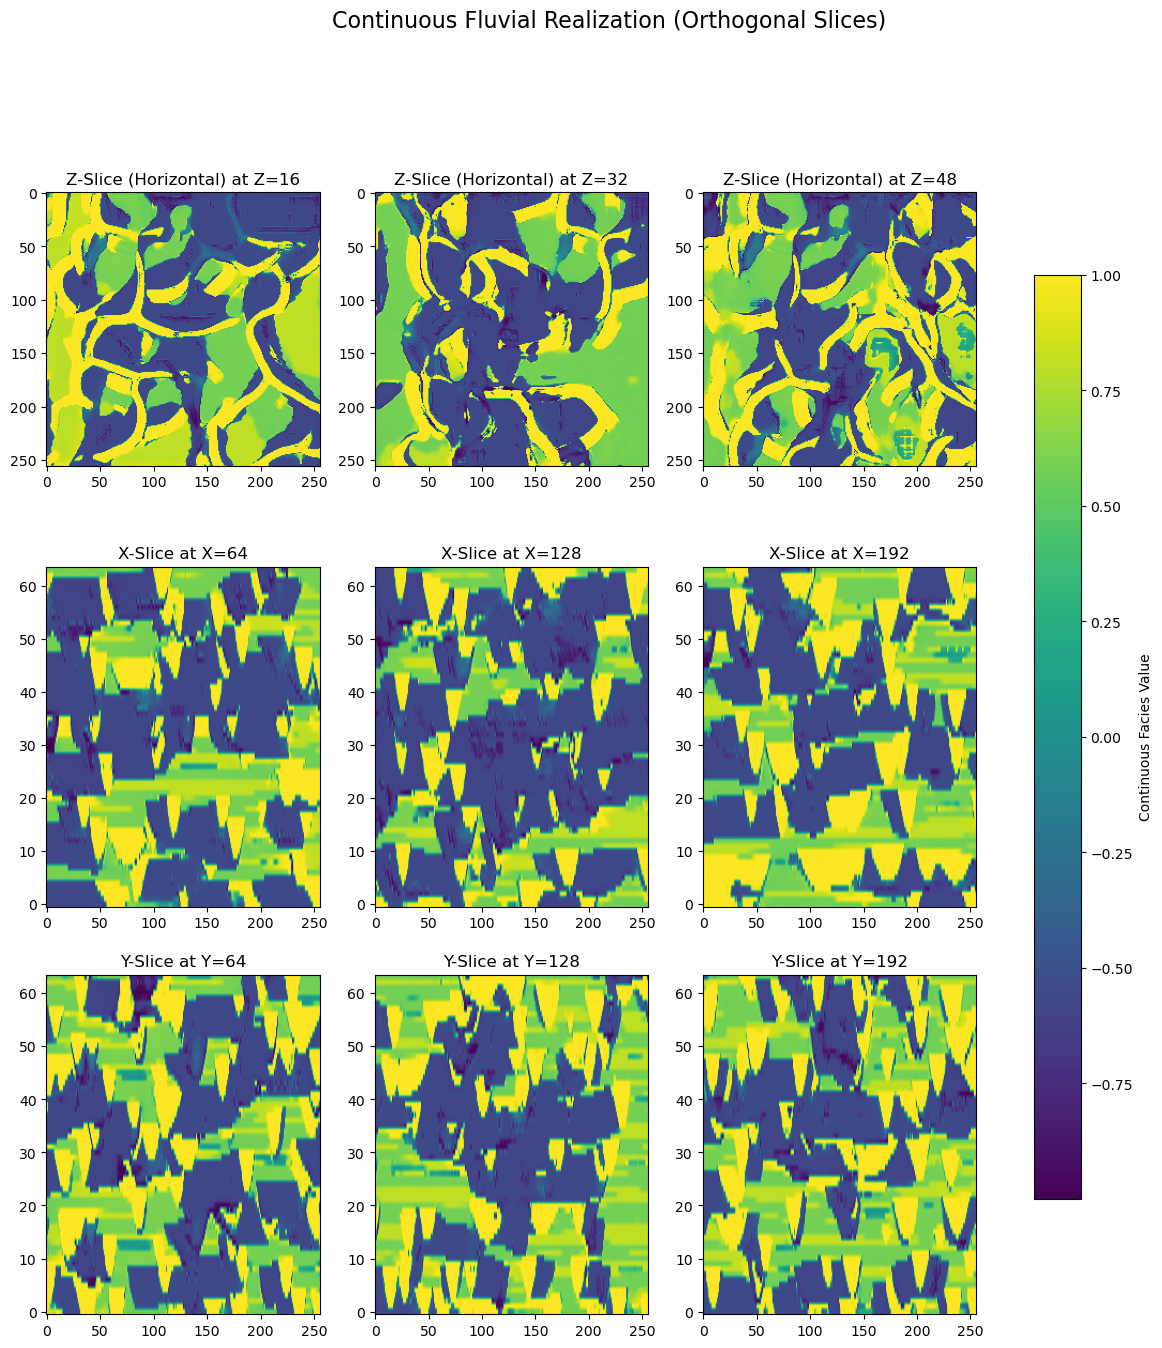

In [20]:
import matplotlib.pyplot as plt

# 1. Get dimensions
dim_z, dim_y, dim_x = volume.shape
print(f"Generated volume shape: {volume.shape}")

# 2. CRITICAL FOR CONTINUOUS DATA: Get global min and max
v_min, v_max = volume.min(), volume.max()
cmap_style = 'viridis'

# 3. Calculate slice indices (roughly 25%, 50%, and 75%)
z_slices = [dim_z // 4, dim_z // 2, 3 * dim_z // 4]
x_slices = [dim_x // 4, dim_x // 2, 3 * dim_x // 4]
y_slices = [dim_y // 4, dim_y // 2, 3 * dim_y // 4]

# 4. Create the 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# Vertical exaggeration stretch for the cross-sections
cross_section_aspect = 'auto' 

for i in range(3):
    # --- Row 1: Z-axis slices (Horizontal / XY plane) ---
    z_idx = z_slices[i]
    # Z-slices are top-down map views, so standard origin (top-left) is used
    im = axes[0, i].imshow(volume[z_idx, :, :], cmap=cmap_style, vmin=v_min, vmax=v_max)
    axes[0, i].set_title(f"Z-Slice (Horizontal) at Z={z_idx}")
    
    # --- Row 2: X-axis slices (Cross-section / YZ plane) ---
    x_idx = x_slices[i]
    # Use origin='lower' to keep the channels right-side up
    axes[1, i].imshow(volume[:, :, x_idx], cmap=cmap_style, vmin=v_min, vmax=v_max, 
                      aspect=cross_section_aspect, origin='lower')
    axes[1, i].set_title(f"X-Slice at X={x_idx}")
    
    # --- Row 3: Y-axis slices (Cross-section / XZ plane) ---
    y_idx = y_slices[i]
    # Use origin='lower' to keep the channels right-side up
    axes[2, i].imshow(volume[:, y_idx, :], cmap=cmap_style, vmin=v_min, vmax=v_max, 
                      aspect=cross_section_aspect, origin='lower')
    axes[2, i].set_title(f"Y-Slice at Y={y_idx}")

# Add a single colorbar for the whole figure, labeled for continuous data
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label='Continuous Facies Value')

plt.suptitle("Continuous Fluvial Realization (Orthogonal Slices)", fontsize=16)
plt.show()

## One hot encoding

Building Generator...
Loading Checkpoint...
Success! Weights are perfectly aligned.
Generating 3D River Block...
Success! Generated 3D block shape: (64, 256, 256)
Unique facies present: [0 1 2]


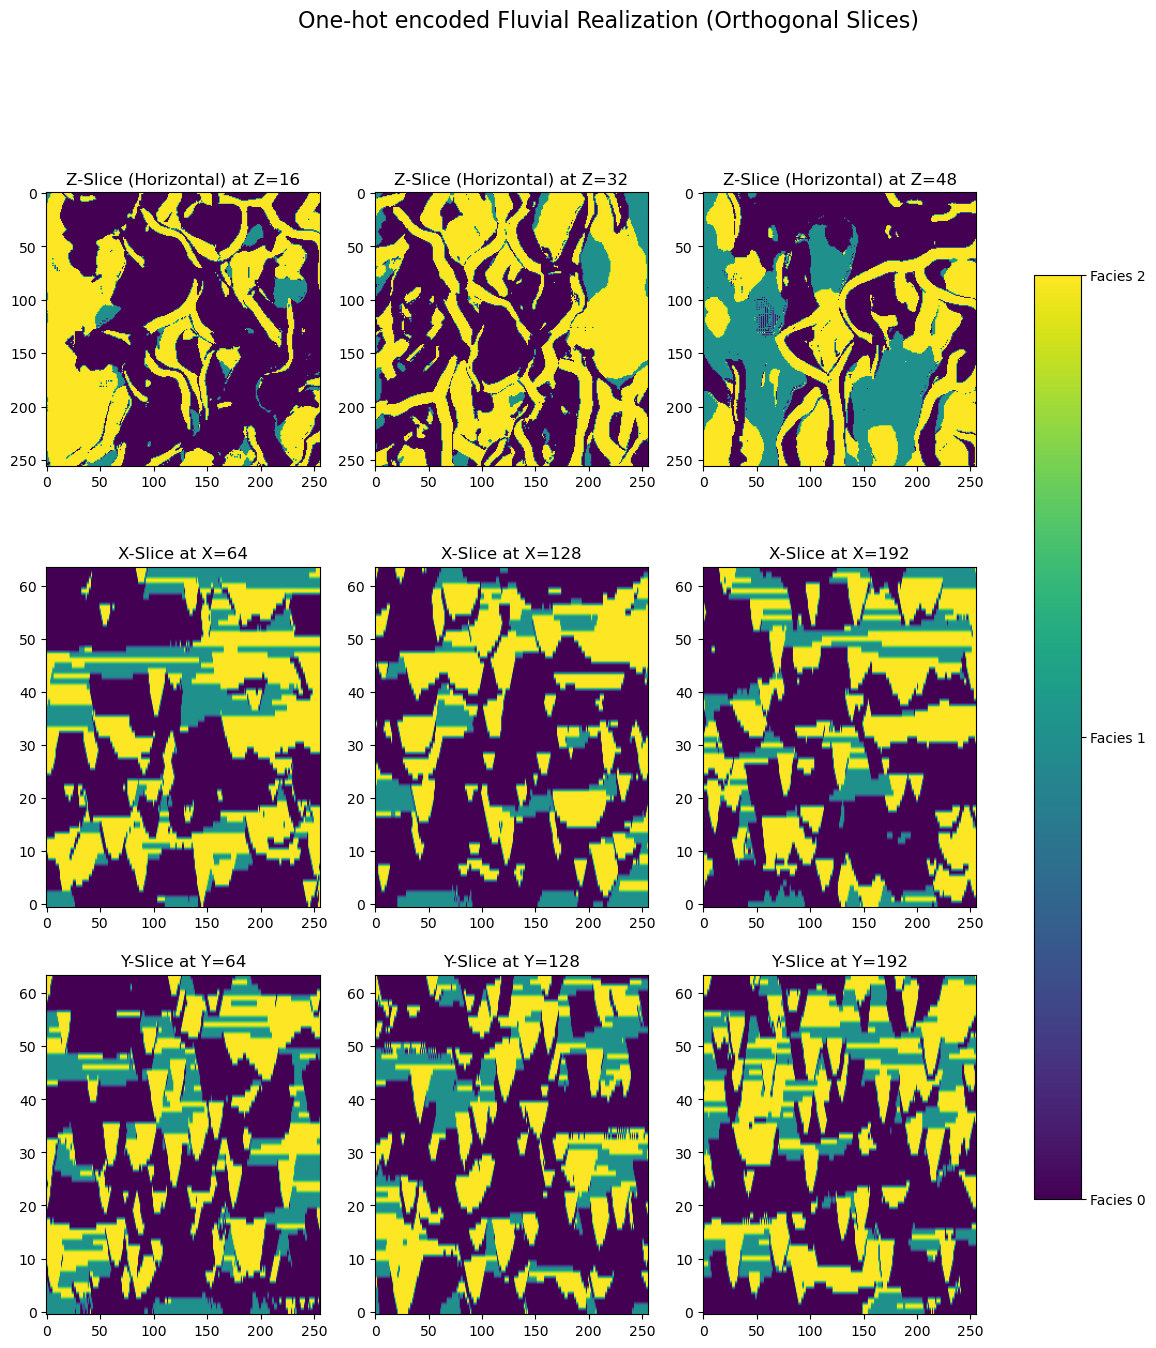

In [21]:
checkpoint_path = "fluvgan_1_training_1_architecture_4_dcgan_one_hot_1_training_checkpoint_iteration_22450.pt"

from functools import partial

nz = 100
nc = 3               # THE FIX: 3 channels for one-hot encoding
ngf = 64             
max_factor = 16      
nl = (4, 6, 6)       

print("Building Generator...")
gen_layer = resnet.DeepGenerator3d(
    nz=nz,
    ngf=ngf,
    nc=nc,
    nl=nl,
    max_factor=max_factor,
    residual_weight=1.,
    mode='nearest',
    kernel_size=3,
    layer_normalization=nn.BatchNorm3d,
    last_layer_normalization=nn.BatchNorm3d,
    weight_normalization=nn.utils.parametrizations.spectral_norm,
    activation=partial(nn.LeakyReLU, negative_slope=0.2, inplace=True),
    last_activation=partial(nn.Softmax, dim=1), # THE FIX: Softmax instead of Tanh
    use_double_conv=False,
    use_double_resblocks=False,
    use_attention=False,
    skip_z=False,
    split_z=False
)

print("Loading Checkpoint...")
checkpoint = torch.load(checkpoint_path, map_location='cpu')

gen_state = checkpoint['generator']
if 'state_dict' in gen_state:
    gen_state = gen_state['state_dict']

gen_layer = nn.DataParallel(gen_layer)
gen_layer.load_state_dict(gen_state, strict=False)

gen_layer = gen_layer.module
gen_layer.eval()
print("Success! Weights are perfectly aligned.")
print("Generating 3D River Block...")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gen_layer = gen_layer.to(device)

num_samples = 1  
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gen_layer = gen_layer.to(device)

z = torch.randn(num_samples, nz, 1, 1, 1, device=device)

with torch.no_grad():
    fake_blocks = gen_layer(z)

fake_blocks_np = fake_blocks.cpu().numpy()
sample_3d_discrete = np.argmax(fake_blocks_np[0], axis=0)

print(f"Success! Generated 3D block shape: {sample_3d_discrete.shape}")
print(f"Unique facies present: {np.unique(sample_3d_discrete)}")

depth = sample_3d_discrete.shape[0]
dim_z, dim_y, dim_x = sample_3d_discrete.shape

# 2. Calculate slice indices
z_slices = [dim_z // 4, dim_z // 2, 3 * dim_z // 4]
x_slices = [dim_x // 4, dim_x // 2, 3 * dim_x // 4]
y_slices = [dim_y // 4, dim_y // 2, 3 * dim_y // 4]

# 3. Create the 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# Vertical exaggeration stretch
cross_section_aspect = 'auto' 

for i in range(3):
    # --- Row 1: Z-axis slices (Horizontal / XY plane) ---
    z_idx = z_slices[i]
    # Z-slices are top-down map views, so standard origin is fine
    im = axes[0, i].imshow(sample_3d_discrete[z_idx, :, :], cmap='viridis', vmin=0, vmax=2)
    axes[0, i].set_title(f"Z-Slice (Horizontal) at Z={z_idx}")
    
    # --- Row 2: X-axis slices (Cross-section / YZ plane) ---
    x_idx = x_slices[i]
    # Added origin='lower' to flip the channels right-side up
    axes[1, i].imshow(sample_3d_discrete[:, :, x_idx], cmap='viridis', vmin=0, vmax=2, aspect=cross_section_aspect, origin='lower')
    axes[1, i].set_title(f"X-Slice at X={x_idx}")
    
    # --- Row 3: Y-axis slices (Cross-section / XZ plane) ---
    y_idx = y_slices[i]
    # Added origin='lower' to flip the channels right-side up
    axes[2, i].imshow(sample_3d_discrete[:, y_idx, :], cmap='viridis', vmin=0, vmax=2, aspect=cross_section_aspect, origin='lower')
    axes[2, i].set_title(f"Y-Slice at Y={y_idx}")

# Add the colorbar
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), ticks=[0, 1, 2], shrink=0.8)
cbar.ax.set_yticklabels(['Facies 0', 'Facies 1', 'Facies 2'])

plt.suptitle("One-hot encoded Fluvial Realization (Orthogonal Slices)", fontsize=16)
plt.show()